# Formative 1, Part 2 — Classical ML Classification Challenge
### Starter Notebook

**Your name(s):** _BODE MURAI MURAIRI_
**Kaggle username:** _BodeMMB@230_
**Competition link:** _https://www.kaggle.com/competitions/sept-2026-trimester-formative-1-part-2-classification_
**W&B project link:** _https://wandb.ai/b-murairi-african-leadership-university/formative1-part2-BodeMurairi?nw=nwuserbmurairi_

---

## 1. Introduction

This implementation is for our in-classes Kaggle binary classification challenge on synthetic dataset. We are predicting target column-a binary outcome with roughly 26% positive rate, from 37 numeric + 3 categorical features. For this competition, we are optimizing ROC-AUC, which is well suited metric for class imbalance- by utilizing data engineering and different classical ML models.

## 2. Setup

Run this first. It installs/imports what you need and locates the data whether you're running in **Kaggle Notebooks**, **Google Colab**, or **locally**.


In [1]:
!pip install wandb
!pip install python-dotenv
!pip install catboost
!pip install xgboost

In [2]:
import numpy as np
import pandas as pd
import os

pd.set_option("display.max_columns", 50)

# --- Locate the data automatically across common environments ---
CANDIDATE_DIRS = [
    "/kaggle/input",                 # Kaggle Notebooks (competition attached)
    "/content",                      # Google Colab (if you've uploaded/mounted files)
    ".",                             # local / same-folder
]

def find_data_dir():
    for base in CANDIDATE_DIRS:
        if not os.path.isdir(base):
            continue
        for root, dirs, files in os.walk(base):
            if "train.csv" in files and "test.csv" in files:
                return root
    return None

DATA_DIR = find_data_dir()
if DATA_DIR is None:
    print("Could not auto-locate train.csv/test.csv.")
    print("If you're on Colab: upload the files or mount Drive, then set DATA_DIR manually below.")
    print("If you're on Kaggle: make sure you've clicked 'Add Data' and attached this competition's dataset.")
else:
    print(f"Found data in: {DATA_DIR}")


Found data in: ./data


In [3]:
# If auto-detection above failed, set the path manually and re-run:
# DATA_DIR = "/content"  # example for Colab after uploading files

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print("train shape:", train.shape)
print("test shape:", test.shape)
train.head()


train shape: (30000, 42)
test shape: (20000, 41)


,id,num_feat_1,num_feat_2,num_feat_3,num_feat_4,num_feat_5,num_feat_6,num_feat_7,num_feat_8,num_feat_9,num_feat_10,num_feat_11,num_feat_12,num_feat_13,num_feat_14,num_feat_15,num_feat_16,num_feat_17,num_feat_18,num_feat_19,num_feat_20,num_feat_21,num_feat_22,num_feat_23,num_feat_24,num_feat_25,num_feat_26,num_feat_27,num_feat_28,num_feat_29,num_feat_30,num_feat_31,num_feat_32,num_feat_33,num_feat_34,num_feat_35,num_feat_36,num_feat_37,target,cat_region,cat_channel,cat_tier
0,row_018856,53.626073,219.076922,-1.810418,-0.159420,-1.322927,-1.615779,-1.138688,-1.615779,440.480154,-0.462100,0.108772,-5.936963,-0.185195,-1.881949,0.246464,0.826256,-1.057580,0.108772,-1.318475,-2.235114,-0.959830,-1.156057,-0.059925,-0.245132,-0.116658,-1.414168,-0.346913,0.992204,-0.040909,-0.580007,-0.924984,2.022967,-1.448010,-5.936963,0.604118,-1.753739,3.513546,0,NaN,A,mid
1,row_006719,49.359204,265.360142,4.785189,0.716050,-3.205241,0.429366,0.931481,0.429366,584.716366,0.924627,0.188854,2.066225,-1.300119,1.214380,1.651118,-1.342908,-1.792503,0.188854,1.004346,0.343773,-1.821677,0.151268,1.304049,2.911428,-1.109803,-0.002200,-2.205452,0.602929,0.179281,-0.837898,-1.646054,1.401412,-0.461406,2.066225,-0.057929,0.284302,-0.448172,0,west,A,premium
2,row_019939,45.478030,269.635184,-0.459811,-0.833381,-10.733651,-1.419081,0.840414,-1.419081,410.088750,-0.595566,0.793924,2.803522,1.116623,0.055337,0.789404,-0.736747,-0.761520,0.793924,-1.124257,3.487690,-1.953597,-0.345494,-2.686015,0.111186,-0.693300,0.137143,-2.082967,0.834090,0.576379,0.279864,-0.248444,-0.712586,0.158244,2.803522,-0.750182,-0.219530,-1.784669,0,north,B,high
3,row_049700,41.382625,248.859070,-2.269038,-0.435875,-10.932748,-3.039297,2.309878,-3.039297,NaN,1.280264,0.720175,-1.701442,-0.169711,2.216673,-0.154421,0.622095,-0.866985,0.720175,0.100486,0.444702,1.756955,-0.990839,-2.451822,-0.596345,1.283076,-2.010829,0.285625,-1.351706,3.979984,-1.618192,-0.019561,1.340699,0.976403,-1.701442,-1.242906,-0.917480,3.154757,1,north,B,mid
4,row_034441,48.776219,275.072954,-0.612385,-0.862517,5.776743,0.573600,-0.206202,0.573600,412.232672,2.227842,-0.261678,-2.724663,-0.329211,-4.051718,-1.868820,1.437544,2.258611,-0.261678,-0.166389,1.789425,-0.516547,-0.980686,2.112079,0.249812,-0.972985,0.706888,-4.977925,1.572550,0.124265,1.166693,2.527783,1.386738,0.657527,-2.724663,0.848977,0.978382,2.601208,0,north,C,high


## 3. Data Understanding

_Replace/extend this section with your own exploration. The baseline below does the bare minimum (shape, class balance, missingness) — you're expected to go further: distributions, correlations, a PCA or similar visualization, and a written interpretation of what you find. Remember: individual feature correlations with the target may look weak even where real signal exists — don't conclude "no signal" too quickly._


In [4]:
target_col = "target"
feature_cols = [c for c in train.columns if c not in ("id", target_col)]
num_cols = [c for c in feature_cols if c.startswith("num_feat")]
cat_cols = [c for c in feature_cols if c.startswith("cat_")]

print(f"{len(num_cols)} numeric features, {len(cat_cols)} categorical features")
print("\nClass balance:")
print(train[target_col].value_counts(normalize=True).round(3))

print("\nMissingness (columns with any missing values):")
miss = train.isnull().mean()
print(miss[miss > 0].sort_values(ascending=False).round(3))


37 numeric features, 3 categorical features

Class balance:
target
0    0.738
1    0.262
Name: proportion, dtype: float64

Missingness (columns with any missing values):
num_feat_7    0.119
num_feat_2    0.110
num_feat_4    0.082
num_feat_9    0.065
cat_region    0.050
dtype: float64


## 4. Experiment Tracking Setup (Weights & Biases)

Set this up **before** training anything, so your baseline run below is logged like every run after it.

Store your API key as a secret — never hardcode it in this notebook:
- **Google Colab:** left sidebar → key icon → add secret named `WANDB_API_KEY`
- **Kaggle Notebooks:** Add-ons menu → Secrets → add `WANDB_API_KEY`

This cell is written defensively: if W&B isn't set up yet, the rest of the notebook still runs — you just won't get tracking until you fix it. Don't leave it broken for long; ungraded/unlogged runs don't count.


### This current notebook was developped and run locally.some section uses local specific setup. If running on Google colab, comment out wandb.login(key=os.getenv("WANDB_API_KEY")) and uncomment these two lines instead
```
Google Colab:
# from google.colab import userdata
# # wandb.login(key=userdata.get("WANDB_API_KEY"))
```

In [37]:
import os
import warnings

warnings.filterwarnings("ignore")

from dotenv import load_dotenv

load_dotenv()

WANDB_ENABLED = True
WANDB_PROJECT = "formative1-part2-BodeMurairi"  # <-- change this

try:
    import wandb
    logged_in = True

    # --- Uncomment the block matching your environment, then set logged_in = True ---

    # Google Colab:
    # from google.colab import userdata
    # wandb.login(key=userdata.get("WANDB_API_KEY"))
    
    wandb.login(key=os.getenv("WANDB_API_KEY"))

    logged_in = True

    # Kaggle Notebooks:
    # from kaggle_secrets import UserSecretsClient
    # wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    # logged_in = True

    WANDB_ENABLED = logged_in
    if WANDB_ENABLED:
        print("W&B ready. Runs will be logged to project:", WANDB_PROJECT)
    else:
        print("W&B installed but not logged in yet — uncomment the block above for your environment.")
        print("Until then, the notebook still runs, but NOTHING is being tracked.")
except Exception as e:
    print("W&B not available — runs will NOT be logged until you fix this.")
    print("Reason:", e)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/bode-murairi/.netrc


W&B ready. Runs will be logged to project: formative1-part2-BodeMurairi


### Reusable experiment logger

Every model you train from here on — baseline or otherwise — should go through this function. It fits your pipeline, evaluates it (holdout + cross-validation ROC-AUC), logs everything to W&B (config, metrics, confusion matrix), and keeps a local record you'll use to build your results table in Section 8.

You should not need to touch this function. Call it once per experiment with a descriptive `run_name` and a `config` dict describing what's different about that run.


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

RANDOM_STATE = 42
results_log = []  # every experiment's summary lands here -> becomes your results table in Section 8

def log_experiment(run_name, pipeline, config, X_train, y_train, X_val, y_val, do_cv=True, X_full=None, y_full=None):
    '''
    Fits `pipeline`, evaluates it, logs to W&B (if enabled), and records
    a row for the results table. Returns the fitted pipeline.

    run_name : short descriptive string, e.g. "rf_depth8_lr0.05"
    config   : dict of whatever you want tracked, e.g. {"model": "RandomForest", "max_depth": 8}
    '''
    pipeline.fit(X_train, y_train)
    val_probs = pipeline.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)

    cv_mean, cv_std = None, None
    if do_cv and X_full is not None:
        cv_scores = cross_val_score(
            pipeline, X_full, y_full,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
            scoring="roc_auc",
        )
        cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

    print(f"[{run_name}] validation ROC-AUC = {val_auc:.4f}" + (f", CV ROC-AUC = {cv_mean:.4f} (+/- {cv_std:.4f})" if cv_mean else ""))

    if WANDB_ENABLED:
        try:
            run = wandb.init(project=WANDB_PROJECT, name=run_name, config=config, reinit=True, dir=DATA_DIR)
            log_dict = {"val_roc_auc": val_auc}
            if cv_mean is not None:
                log_dict.update({"cv_roc_auc_mean": cv_mean, "cv_roc_auc_std": cv_std})

            val_preds_hard = (val_probs >= 0.5).astype(int)
            cm = confusion_matrix(y_val, val_preds_hard)
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(cm, cmap="Blues")
            for i in range(2):
                for j in range(2):
                    ax.text(j, i, str(cm[i, j]), ha="center", va="center")
            ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(run_name)
            wandb.log({**log_dict, "confusion_matrix": wandb.Image(fig)})
            plt.close(fig)
            run.finish()
        except Exception as e:
            print(f"  (W&B logging failed for this run: {e} — local results still recorded below)")

    results_log.append({
        "run_name": run_name,
        **config,
        "val_roc_auc": round(val_auc, 4),
        "cv_roc_auc_mean": round(cv_mean, 4) if cv_mean else None,
    })
    return pipeline


## 5. Preprocessing & Baseline Model

This section builds a **logistic regression baseline** end-to-end: impute missing values, scale numeric features, one-hot encode categoricals, then train and log it using `log_experiment(...)` from Section 4.

**This baseline is intentionally simple.** It is not meant to score well — it exists so you have:
1. A working, fully-tracked pipeline you can confirm end-to-end before building anything fancier.
2. A concrete number to beat, already sitting in `results_log` and on your W&B dashboard. If your "improved" model doesn't beat this, something is likely wrong, not just under-tuned.

Do not treat this as your final model. You are required to try at least one other model family (see the assignment instructions) and tune it properly — using the same `log_experiment(...)` pattern.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

X = train[feature_cols]
y = train[target_col]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

baseline_pipeline = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])


In [8]:

baseline_pipeline = log_experiment(
    run_name="baseline-logreg",
    pipeline=baseline_pipeline,
    config={"model": "LogisticRegression", "max_iter": 1000},
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
)


[baseline-logreg] validation ROC-AUC = 0.6567, CV ROC-AUC = 0.6520 (+/- 0.0042)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
val_roc_auc,▁
cv_roc_auc_mean,0.65198
cv_roc_auc_std,0.0042
val_roc_auc,0.65672


## 6. Your Models & Experiments

**This is where your actual work goes.** Use the same `log_experiment(...)` pattern from Section 5 — fit a pipeline, call `log_experiment(run_name=..., pipeline=..., config={...}, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_full=X, y_full=y)` — for every model and every hyperparameter variation you try.

Add at least one classical model family beyond the logistic regression baseline (e.g., decision tree, random forest, SVM, XGBoost, LightGBM), justify your choice in Markdown, and log at least 3 hyperparameter variations per model as required by the assignment.


### Introduction
Before begining our experiment, we will define three helpers functions that will save the model and associated parameters locally after each run, independant of the log_experiment, which only record experiment on wandb. This is to preserve model best hyper-parameters

In [7]:
import joblib
import json

MODELS_DIR = os.path.join("results", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_FOLDERS = {
    "LogisticRegression": "logistic_regression",
    "RandomForestClassifier": "random_forest",
    "XGBClassifier": "xgboost",
    "CatBoostClassifier": "cat",
}

def model_folder(pipeline):
    """This function determines which folder a model's file should go.
    This is done by determining which classifier family the model belongs to.
    results/models/<family>/ - picked from the pipeline's classifier,
    so saving is automatic."""

    steps = getattr(pipeline, "named_steps", {})
    clf = steps["clf"] if "clf" in steps else pipeline
    folder = os.path.join(MODELS_DIR, MODEL_FOLDERS.get(type(clf).__name__, "other"))
    os.makedirs(folder, exist_ok=True)
    return folder

def save_model(run_name, pipeline):
    """This helper function saves a fitted pipeline to disk,
    plus its logged config/metrics, for later retrieval.
    """
    folder = model_folder(pipeline)
    model_path = os.path.join(folder, f"{run_name}.joblib")
    joblib.dump(pipeline, model_path)

    details = next((r for r in reversed(results_log) if r["run_name"] == run_name), None)
    details_path = os.path.join(folder, f"{run_name}.json")
    with open(details_path, "w") as f:
        json.dump(details, f, indent=2, default=str)

    print(f"Saved model -> {model_path}")
    print(f"Saved details -> {details_path}")

def real_config(pipeline, **extra):
    """This function builds the logged config from the classifier's actual params,
    so it cannot drift from the model defined above the log_experiment call.
    """
    clf = pipeline.named_steps["clf"]
    keys = ["n_estimators", "learning_rate", "max_depth", "min_child_weight", "gamma",
            "reg_lambda", "subsample", "colsample_bytree", "colsample_bynode",
            "scale_pos_weight", "criterion", "min_samples_split", "min_samples_leaf",
            "max_features", "C", "penalty", "l1_ratio", "solver", "max_iter", "class_weight"]
    params = clf.get_params()
    config = {"model": type(clf).__name__}
    for k in keys:
        if k not in params:
            continue
        v = params[k]
        if (v is None and k != "max_depth") or (isinstance(v, str) and v == "deprecated"):
            continue
        config[k] = round(float(v), 4) if isinstance(v, float) else v
    return {**config, **extra}


### In-depth dataset understanding and data preprocessing

In [8]:
train.head()

,id,num_feat_1,num_feat_2,num_feat_3,num_feat_4,num_feat_5,num_feat_6,num_feat_7,num_feat_8,num_feat_9,num_feat_10,num_feat_11,num_feat_12,num_feat_13,num_feat_14,num_feat_15,num_feat_16,num_feat_17,num_feat_18,num_feat_19,num_feat_20,num_feat_21,num_feat_22,num_feat_23,num_feat_24,num_feat_25,num_feat_26,num_feat_27,num_feat_28,num_feat_29,num_feat_30,num_feat_31,num_feat_32,num_feat_33,num_feat_34,num_feat_35,num_feat_36,num_feat_37,target,cat_region,cat_channel,cat_tier
0,row_018856,53.626073,219.076922,-1.810418,-0.159420,-1.322927,-1.615779,-1.138688,-1.615779,440.480154,-0.462100,0.108772,-5.936963,-0.185195,-1.881949,0.246464,0.826256,-1.057580,0.108772,-1.318475,-2.235114,-0.959830,-1.156057,-0.059925,-0.245132,-0.116658,-1.414168,-0.346913,0.992204,-0.040909,-0.580007,-0.924984,2.022967,-1.448010,-5.936963,0.604118,-1.753739,3.513546,0,NaN,A,mid
1,row_006719,49.359204,265.360142,4.785189,0.716050,-3.205241,0.429366,0.931481,0.429366,584.716366,0.924627,0.188854,2.066225,-1.300119,1.214380,1.651118,-1.342908,-1.792503,0.188854,1.004346,0.343773,-1.821677,0.151268,1.304049,2.911428,-1.109803,-0.002200,-2.205452,0.602929,0.179281,-0.837898,-1.646054,1.401412,-0.461406,2.066225,-0.057929,0.284302,-0.448172,0,west,A,premium
2,row_019939,45.478030,269.635184,-0.459811,-0.833381,-10.733651,-1.419081,0.840414,-1.419081,410.088750,-0.595566,0.793924,2.803522,1.116623,0.055337,0.789404,-0.736747,-0.761520,0.793924,-1.124257,3.487690,-1.953597,-0.345494,-2.686015,0.111186,-0.693300,0.137143,-2.082967,0.834090,0.576379,0.279864,-0.248444,-0.712586,0.158244,2.803522,-0.750182,-0.219530,-1.784669,0,north,B,high
3,row_049700,41.382625,248.859070,-2.269038,-0.435875,-10.932748,-3.039297,2.309878,-3.039297,NaN,1.280264,0.720175,-1.701442,-0.169711,2.216673,-0.154421,0.622095,-0.866985,0.720175,0.100486,0.444702,1.756955,-0.990839,-2.451822,-0.596345,1.283076,-2.010829,0.285625,-1.351706,3.979984,-1.618192,-0.019561,1.340699,0.976403,-1.701442,-1.242906,-0.917480,3.154757,1,north,B,mid
4,row_034441,48.776219,275.072954,-0.612385,-0.862517,5.776743,0.573600,-0.206202,0.573600,412.232672,2.227842,-0.261678,-2.724663,-0.329211,-4.051718,-1.868820,1.437544,2.258611,-0.261678,-0.166389,1.789425,-0.516547,-0.980686,2.112079,0.249812,-0.972985,0.706888,-4.977925,1.572550,0.124265,1.166693,2.527783,1.386738,0.657527,-2.724663,0.848977,0.978382,2.601208,0,north,C,high


In [9]:
# Check for NAN
miss = train.isnull().mean()
print(miss[miss > 0].sort_values(ascending=False).round(3))

num_feat_7    0.119
num_feat_2    0.110
num_feat_4    0.082
num_feat_9    0.065
cat_region    0.050
dtype: float64


### First check if there if any linear relationship

In [10]:
# Check correlation with target before preprocessing
train[num_cols].corr()

,num_feat_1,num_feat_2,num_feat_3,num_feat_4,num_feat_5,num_feat_6,num_feat_7,num_feat_8,num_feat_9,num_feat_10,num_feat_11,num_feat_12,num_feat_13,num_feat_14,num_feat_15,num_feat_16,num_feat_17,num_feat_18,num_feat_19,num_feat_20,num_feat_21,num_feat_22,num_feat_23,num_feat_24,num_feat_25,num_feat_26,num_feat_27,num_feat_28,num_feat_29,num_feat_30,num_feat_31,num_feat_32,num_feat_33,num_feat_34,num_feat_35,num_feat_36,num_feat_37
num_feat_1,1.000000,-0.316257,-0.030835,0.006105,0.431282,0.298742,-0.005869,0.298742,-0.002603,-0.008445,-0.183163,-0.226747,0.002347,-0.176355,0.488310,0.126582,0.002813,-0.183163,-0.001977,-0.213485,-0.004281,0.136208,0.002016,-0.089718,0.014813,-0.533979,0.319821,0.003774,-0.365706,0.258024,-0.232181,-0.264752,-0.002065,-0.226747,0.002997,-0.002075,-0.072239
num_feat_2,-0.316257,1.000000,0.176265,0.014808,0.030013,0.462816,0.005115,0.462816,-0.002085,0.004884,0.151860,0.321479,-0.013589,0.431357,-0.287749,0.156558,0.005016,0.151860,0.001175,0.400003,-0.005497,0.267231,-0.009142,-0.299723,-0.003329,0.225717,-0.141171,-0.000320,-0.039413,-0.134841,-0.267259,0.493962,-0.000177,0.321479,0.002834,0.005329,0.257057
num_feat_3,-0.030835,0.176265,1.000000,0.001739,0.257316,0.212633,0.004699,0.212633,-0.007409,-0.002443,-0.234800,0.258621,-0.002313,0.330116,0.219874,0.219828,0.006612,-0.234800,0.004559,-0.092479,-0.000746,-0.300549,0.008834,0.399419,0.009410,0.346817,-0.087801,0.009262,-0.088531,0.427150,0.354127,0.281923,0.004491,0.258621,-0.008713,-0.002955,-0.119659
num_feat_4,0.006105,0.014808,0.001739,1.000000,0.017502,0.008346,-0.001012,0.008346,0.005850,0.006190,-0.001168,0.005484,0.000258,0.001047,-0.008568,0.013657,-0.003049,-0.001168,-0.003028,0.003587,-0.002677,0.013994,-0.001919,-0.005156,-0.007364,-0.006303,-0.006933,-0.003293,-0.002626,0.008663,-0.004183,0.014311,0.005828,0.005484,0.004294,-0.003737,0.020581
num_feat_5,0.431282,0.030013,0.257316,0.017502,1.000000,0.359636,-0.002473,0.359636,0.000227,-0.002994,-0.440174,0.251362,-0.001483,0.062598,-0.162291,0.387253,-0.001778,-0.440174,0.014984,-0.302200,-0.002830,0.428518,-0.000083,0.134902,-0.003312,-0.053662,-0.064029,0.001326,0.104010,0.496352,0.289838,-0.066072,0.003414,0.251362,-0.000447,0.006665,0.233951
num_feat_6,0.298742,0.462816,0.212633,0.008346,0.359636,1.000000,-0.001637,1.000000,-0.006519,-0.001382,0.046330,-0.118663,-0.006846,0.038365,-0.052904,0.040578,0.014160,0.046330,0.004065,0.039140,0.000337,0.024689,0.001052,-0.016830,-0.001576,0.071231,0.174077,-0.004617,-0.099376,-0.067347,-0.064111,0.059459,0.002788,-0.118663,0.005410,0.005247,-0.057175
num_feat_7,-0.005869,0.005115,0.004699,-0.001012,-0.002473,-0.001637,1.000000,-0.001637,0.005392,0.004812,0.001803,-0.000179,0.008218,0.007978,-0.004827,0.005944,0.002585,0.001803,-0.004097,-0.004126,-0.000284,-0.004470,0.004151,-0.002770,-0.001745,0.004720,0.003183,-0.000920,-0.004254,-0.002250,0.002191,0.003822,-0.003896,-0.000179,0.006260,0.014298,0.003654
num_feat_8,0.298742,0.462816,0.212633,0.008346,0.359636,1.000000,-0.001637,1.000000,-0.006519,-0.001382,0.046330,-0.118663,-0.006846,0.038365,-0.052904,0.040578,0.014160,0.046330,0.004065,0.039140,0.000337,0.024689,0.001052,-0.016830,-0.001576,0.071231,0.174077,-0.004617,-0.099376,-0.067347,-0.064111,0.059459,0.002788,-0.118663,0.005410,0.005247,-0.057175
num_feat_9,-0.002603,-0.002085,-0.007409,0.005850,0.000227,-0.006519,0.005392,-0.006519,1.000000,0.003503,0.009875,0.003435,0.012619,0.003875,0.001211,-0.000033,0.001324,0.009875,-0.002009,0.001607,-0.002022,0.008004,0.008865,0.000394,-0.007508,-0.007468,-0.000428,0.003068,0.014975,0.003002,0.005291,-0.002592,-0.008723,0.003435,-0.002728,0.007785,0.008159
num_feat_10,-0.008445,0.004884,-0.002443,0.006190,-0.002994,-0.001382,0.004812,-0.001382,0.003503,1.000000,0.000443,0.001014,-0.001498,-0.002272,0.001232,0.000638,-0.012875,0.000443,0.007817,0.004294,-0.009472,0.007752,0.002414,0.000739,-0.009182,0.006206,-0.014213,-0.000081,0.007569,-0.008947,-0.003882,0.009241,-0.006256,0.00

In [11]:
import numpy as np

corr = train[num_cols].corr()
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.where(mask).stack().sort_values(key=abs, ascending=False)
pairs


num_feat_6   num_feat_8     1.000000
num_feat_11  num_feat_18    1.000000
num_feat_12  num_feat_34    1.000000
num_feat_1   num_feat_26   -0.533979
num_feat_12  num_feat_22    0.521614
                              ...   
num_feat_10  num_feat_28   -0.000081
num_feat_13  num_feat_33    0.000077
             num_feat_23    0.000061
num_feat_9   num_feat_16   -0.000033
num_feat_13  num_feat_19    0.000014
Length: 666, dtype: float64

### Correlation with the target

The correlation matrix shows that individual numeric features have weak linear relationships with the target: the strongest, `num_feat_31`, reaches only r = 0.06, and the rest are minimal. The matrix does, however, reveal meaningful structure among the features themselves: three pairs (`num_feat_6`/`8`, `num_feat_11`/`18`, `num_feat_12`/`34`) are exact duplicates (r = 1.0), and a handful of other pairs `num_feat_1`/`num_feat_26`, `num_feat_12`/`num_feat_22`, `num_feat_5`/`num_feat_30` show moderate correlation r = 0.49–0.53. Taken alone, the weak feature-target correlations might suggest the dataset carries very little linear relationship.


### check categorical values distribution

In [54]:
train.head()

,id,num_feat_1,num_feat_2,num_feat_3,num_feat_4,num_feat_5,num_feat_6,num_feat_7,num_feat_8,num_feat_9,num_feat_10,num_feat_11,num_feat_12,num_feat_13,num_feat_14,num_feat_15,num_feat_16,num_feat_17,num_feat_18,num_feat_19,num_feat_20,num_feat_21,num_feat_22,num_feat_23,num_feat_24,num_feat_25,num_feat_26,num_feat_27,num_feat_28,num_feat_29,num_feat_30,num_feat_31,num_feat_32,num_feat_33,num_feat_34,num_feat_35,num_feat_36,num_feat_37,target,cat_region,cat_channel,cat_tier
0,row_018856,53.626073,219.076922,-1.810418,-0.159420,-1.322927,-1.615779,-1.138688,-1.615779,440.480154,-0.462100,0.108772,-5.936963,-0.185195,-1.881949,0.246464,0.826256,-1.057580,0.108772,-1.318475,-2.235114,-0.959830,-1.156057,-0.059925,-0.245132,-0.116658,-1.414168,-0.346913,0.992204,-0.040909,-0.580007,-0.924984,2.022967,-1.448010,-5.936963,0.604118,-1.753739,3.513546,0,NaN,A,mid
1,row_006719,49.359204,265.360142,4.785189,0.716050,-3.205241,0.429366,0.931481,0.429366,584.716366,0.924627,0.188854,2.066225,-1.300119,1.214380,1.651118,-1.342908,-1.792503,0.188854,1.004346,0.343773,-1.821677,0.151268,1.304049,2.911428,-1.109803,-0.002200,-2.205452,0.602929,0.179281,-0.837898,-1.646054,1.401412,-0.461406,2.066225,-0.057929,0.284302,-0.448172,0,west,A,premium
2,row_019939,45.478030,269.635184,-0.459811,-0.833381,-10.733651,-1.419081,0.840414,-1.419081,410.088750,-0.595566,0.793924,2.803522,1.116623,0.055337,0.789404,-0.736747,-0.761520,0.793924,-1.124257,3.487690,-1.953597,-0.345494,-2.686015,0.111186,-0.693300,0.137143,-2.082967,0.834090,0.576379,0.279864,-0.248444,-0.712586,0.158244,2.803522,-0.750182,-0.219530,-1.784669,0,north,B,high
3,row_049700,41.382625,248.859070,-2.269038,-0.435875,-10.932748,-3.039297,2.309878,-3.039297,NaN,1.280264,0.720175,-1.701442,-0.169711,2.216673,-0.154421,0.622095,-0.866985,0.720175,0.100486,0.444702,1.756955,-0.990839,-2.451822,-0.596345,1.283076,-2.010829,0.285625,-1.351706,3.979984,-1.618192,-0.019561,1.340699,0.976403,-1.701442,-1.242906,-0.917480,3.154757,1,north,B,mid
4,row_034441,48.776219,275.072954,-0.612385,-0.862517,5.776743,0.573600,-0.206202,0.573600,412.232672,2.227842,-0.261678,-2.724663,-0.329211,-4.051718,-1.868820,1.437544,2.258611,-0.261678,-0.166389,1.789425,-0.516547,-0.980686,2.112079,0.249812,-0.972985,0.706888,-4.977925,1.572550,0.124265,1.166693,2.527783,1.386738,0.657527,-2.724663,0.848977,0.978382,2.601208,0,north,C,high


In [55]:
cat_region_value = train[cat_cols].cat_region.value_counts()

print(f"The average cat region is: {cat_region_value.mean()}")
print(f"The max value is: {cat_region_value.max()}")
print(f"The min value is: {cat_region_value.min()}")
print(f"Spread of value is balanced between {cat_region_value.min()} to {cat_region_value.max()}")
print(f"With only {cat_region_value.max() - cat_region_value.min()} difference between the largest and lowest cat regions and a mean value of {cat_region_value.mean()}")
cat_region_value

The average cat region is: 7123.5
The max value is: 7162
The min value is: 7078
Spread of value is balanced between 7078 to 7162
With only 84 difference between the largest and lowest cat regions and a mean value of 7123.5


cat_region
east     7162
south    7139
north    7115
west     7078
Name: count, dtype: int64

In [56]:
cat_channel_value = train[cat_cols].cat_channel.value_counts()

pct_increase = (cat_channel_value.max() - cat_channel_value.min()) / cat_channel_value.min() * 100

print(f"The average cat region is: {cat_channel_value.mean()}")
print(f"The max value is: {cat_channel_value.max()}")
print(f"The min value is: {cat_channel_value.min()}")
print(f"Spread of value is balanced between {cat_channel_value.min()} to {cat_channel_value.max()}")
print(f"With only {cat_channel_value.max() - cat_channel_value.min()} difference between the largest and lowest cat regions and a mean value of {cat_channel_value.mean()}")
print(f"The largest category is {pct_increase:.1f}% bigger than the smallest")
print("")
print(cat_channel_value)
print("")
print ("Percentage increased from smallest to largest")
cat_channel_value.sort_values().pct_change().mul(100).round(1)

The average cat region is: 10000.0
The max value is: 10567
The min value is: 9046
Spread of value is balanced between 9046 to 10567
With only 1521 difference between the largest and lowest cat regions and a mean value of 10000.0
The largest category is 16.8% bigger than the smallest

cat_channel
A    10567
C    10387
B     9046
Name: count, dtype: int64

Percentage increased from smallest to largest


cat_channel
B     NaN
C    14.8
A     1.7
Name: count, dtype: float64

In [57]:
train[cat_cols].cat_tier.value_counts()

cat_tier
mid        7586
high       7503
premium    7461
low        7450
Name: count, dtype: int64

### From the three categorical columns (cat_channel, cat_region, cat_tier), cat_tier seems to follow a natural order: low, mid, high, premium (low < mid < high < premium). However, this assumption is worth checking

              mean  count
cat_tier                 
low       0.256376   7450
mid       0.255075   7586
high      0.241637   7503
premium   0.295537   7461


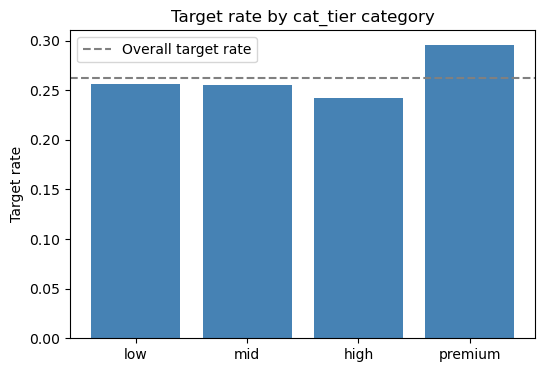

In [16]:
tier_order = ["low", "mid", "high", "premium"]
tier_target_rates = train.groupby("cat_tier")["target"].agg(["mean", "count"]).reindex(tier_order)
print(tier_target_rates)

plt.figure(figsize=(6, 4))
plt.bar(tier_target_rates.index, tier_target_rates["mean"], color="steelblue")
plt.axhline(train["target"].mean(), color="gray", linestyle="--", label="Overall target rate")
plt.ylabel("Target rate")
plt.title("Target rate by cat_tier category")
plt.legend()
plt.show()


### Result
Based on the graph, target rate does not increase or decrease monotonically across low, mid, high, and premium. Low and mid are roughly equal to 0.256, high dips below 0.250, and premium jumps well above the rest but belowe 0.3, a non-monotonic pattern

### handle missing valuess

In [17]:
columns_list = train.columns
features_select = [feat for feat in columns_list if feat not in ("num_feat_8", "num_feat_18", "num_feat_34", "id", "target")]
num_features = [feat for feat in features_select if feat.startswith("num_feat")]
cat_features = [feat for feat in features_select if feat.startswith("cat_")]

## In this experiment, I want to compare two different ways of handling missing values: 
`1. replacing each NAN with column global median`
`2. replacing each NAN with the nearest neighbor` using KNNInputer and evaluate how the two approaches impact performance in logistic regression and other models

First: replace all NAN in the numerical columns with the column median value, then scale every value by substracting the mean and dividing by the variance, then filling missing data in the categorical values with the mode of the column. Provide it in a pipeline for the model

In [21]:
from sklearn.linear_model import LogisticRegression
RANDOM_STATE = 42
preprocess_exp1 = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_features),
])

exp1_pipeline = Pipeline([
    ("prep", preprocess_exp1),
    ("clf", LogisticRegression(
    max_iter=2000,
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    class_weight=None,
    random_state=RANDOM_STATE,
)
),
])

exp1_pipeline = log_experiment(
    run_name="exp1-median-mostfrequent-impute-logistic regression",
    pipeline=exp1_pipeline,
    config=real_config(exp1_pipeline, num_impute="median", cat_impute="most_frequent", dropped_duplicates=True),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
)
save_model(
    run_name="exp1-median-mostfrequent-impute-logistic regression",
    pipeline=exp1_pipeline)

[exp1-median-mostfrequent-impute-logistic regression] validation ROC-AUC = 0.6568, CV ROC-AUC = 0.6520 (+/- 0.0042)


wandb: Currently logged in as: b-murairi (b-murairi-african-leadership-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
val_roc_auc,▁
cv_roc_auc_mean,0.65198
cv_roc_auc_std,0.00419
val_roc_auc,0.65678


Saved model -> results/models/logistic_regression/exp1-median-mostfrequent-impute-logistic regression.joblib
Saved details -> results/models/logistic_regression/exp1-median-mostfrequent-impute-logistic regression.json


In [22]:
from sklearn.impute import KNNImputer

preprocess_knn = ColumnTransformer([
    ("num", Pipeline([
        ("impute", KNNImputer(n_neighbors=5)),
        ("scale", StandardScaler()),
    ]), num_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_features),
])

knn_pipeline = Pipeline([
    ("prep", preprocess_knn),
    ("clf", LogisticRegression(
    max_iter=2000,
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    class_weight=None,
    random_state=RANDOM_STATE,
)),
])

log_experiment(
    run_name="baseline-logreg-knn-impute",
    pipeline=knn_pipeline,
    config=real_config(knn_pipeline, num_impute="knn_k5"),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model(
    run_name="baseline-logreg-knn-impute",
    pipeline=knn_pipeline
)

[baseline-logreg-knn-impute] validation ROC-AUC = 0.6571, CV ROC-AUC = 0.6517 (+/- 0.0041)


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
val_roc_auc,▁
cv_roc_auc_mean,0.65165
cv_roc_auc_std,0.00407
val_roc_auc,0.6571


Saved model -> results/models/logistic_regression/baseline-logreg-knn-impute.joblib
Saved details -> results/models/logistic_regression/baseline-logreg-knn-impute.json


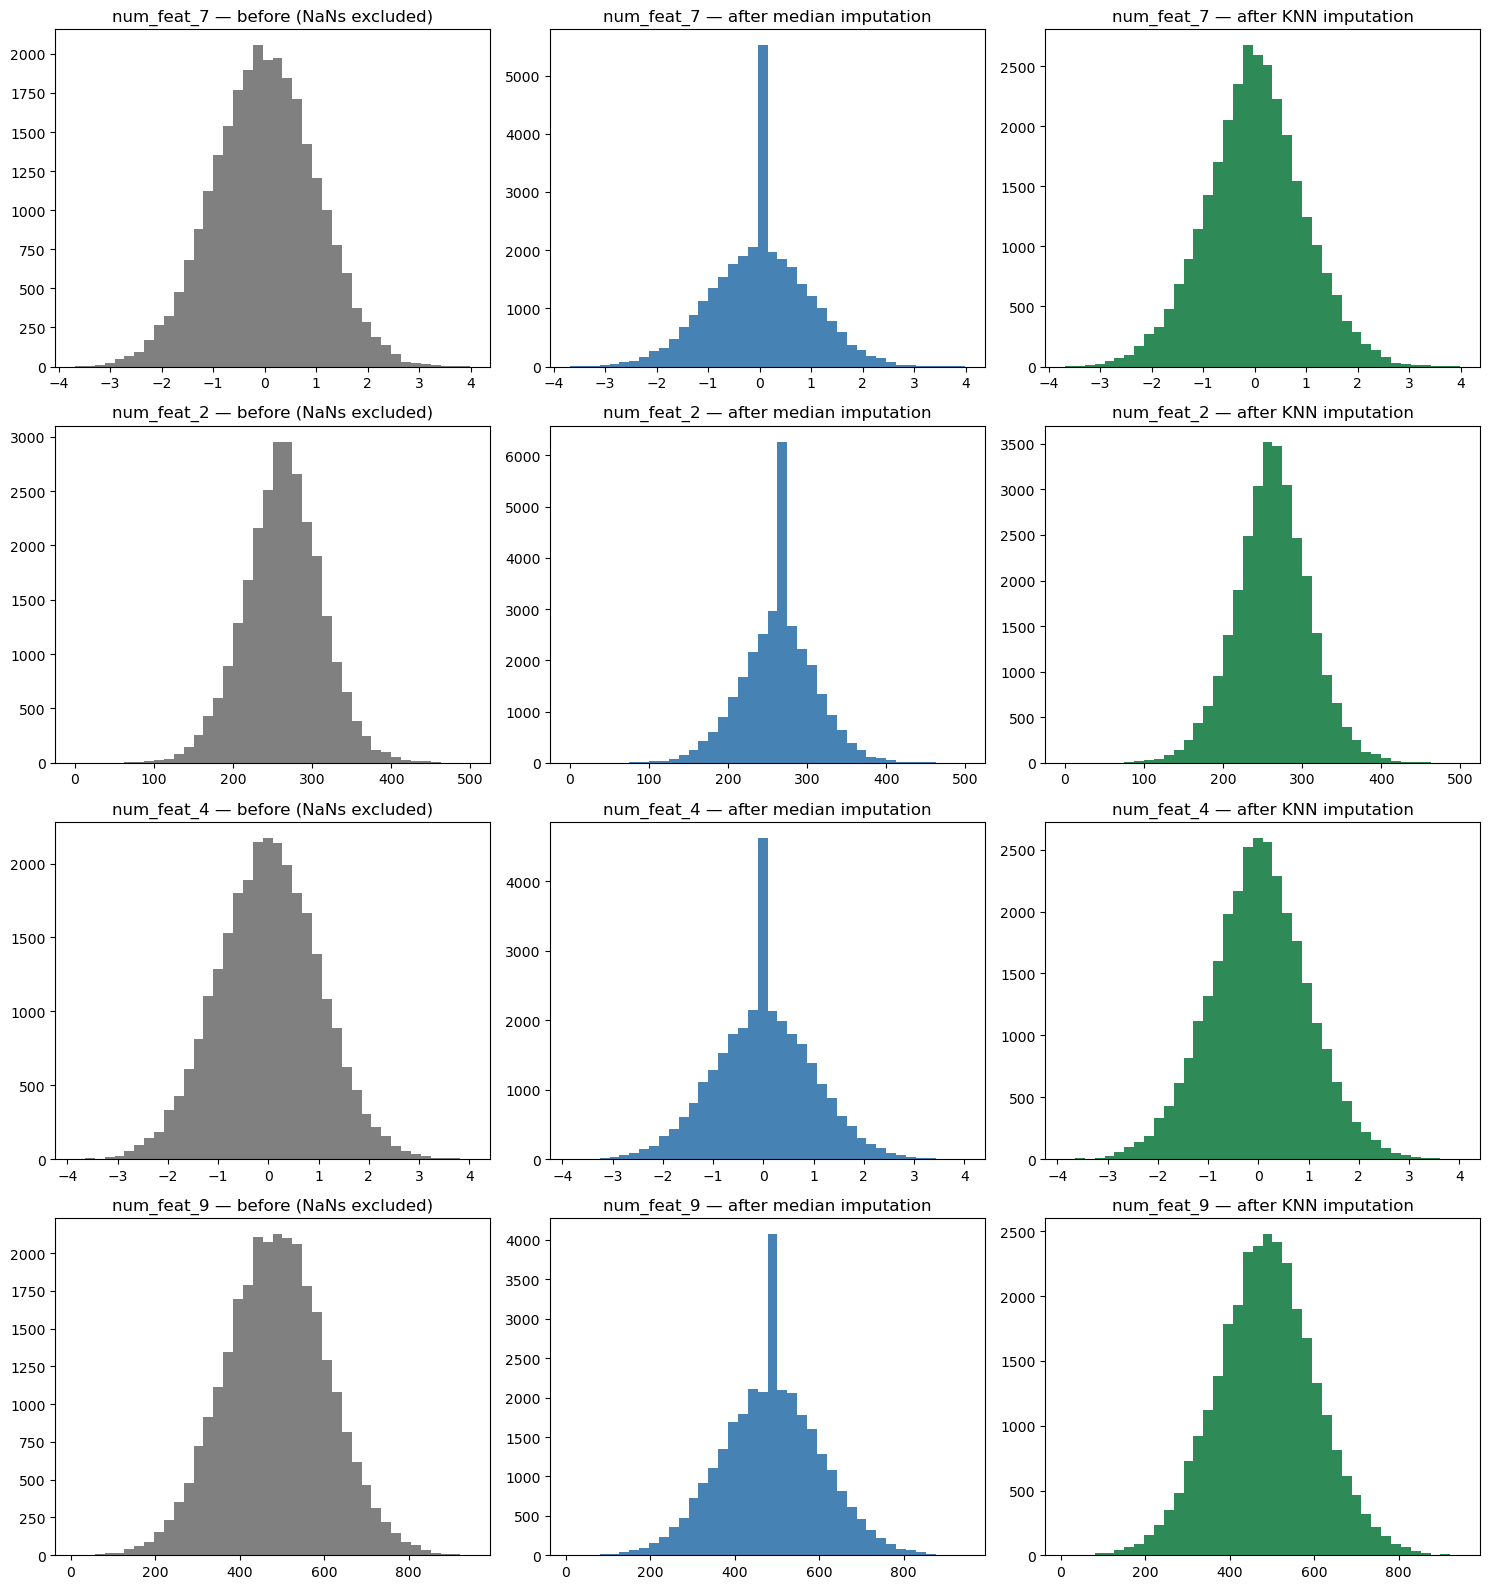

In [23]:
from sklearn.impute import SimpleImputer, KNNImputer

cols_with_missing = ["num_feat_7", "num_feat_2", "num_feat_4", "num_feat_9"]

median_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(train[num_features]),
    columns=num_features
)
knn_imputed = pd.DataFrame(
    KNNImputer(n_neighbors=5).fit_transform(train[num_features]),
    columns=num_features
)

fig, axes = plt.subplots(len(cols_with_missing), 3, figsize=(15, 4 * len(cols_with_missing)))

for i, col in enumerate(cols_with_missing):
    axes[i, 0].hist(train[col].dropna(), bins=40, color="gray")
    axes[i, 0].set_title(f"{col} — before (NaNs excluded)")

    axes[i, 1].hist(median_imputed[col], bins=40, color="steelblue")
    axes[i, 1].set_title(f"{col} — after median imputation")

    axes[i, 2].hist(knn_imputed[col], bins=40, color="seagreen")
    axes[i, 2].set_title(f"{col} — after KNN imputation")

plt.tight_layout()
plt.show()


Median imputation replaces each missing value in a column with a single value, which creates a spike in the distribution because all missing values in the column collapse onto the same point. KNN imputation, on the other hand, estimates each missing value individually, based on the average of that row's k most similar rows by computing distance across the other features. Since each row typically has a different neighborhood, the imputed values vary from row to row, preserving more of the original distribution's spread rather than concentrating missing values at one point(Aguiar Quevedo et al., 2026). 

Under the same hyperparameters, KNN imputation scored marginally higher on the validation split (0.6571 vs 0.6567 for median), but marginally lower on 5-fold CV (0.6517 vs 0.6520), a difference small enough in both directions to be noise rather than a real improvement.

### Attempt to find best parameters for logistic regression using RandomSearch

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

# solver="saga" supports l1, l2, and elasticnet, so one search space covers all penalty types
search_pipeline = Pipeline([
    ("prep", preprocess_exp1),
    ("clf", LogisticRegression(solver="saga", max_iter=2000, random_state=RANDOM_STATE)),
])

param_distributions = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__penalty": ["l1", "l2", "elasticnet"],
    "clf__l1_ratio": uniform(0, 1),
    "clf__class_weight": [None, "balanced"],
}

random_search = RandomizedSearchCV(
    search_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", random_search.best_score_)
print("Best params:", random_search.best_params_)

Best CV ROC-AUC: 0.6528097533212622
Best params: {'clf__C': np.float64(0.033205591037519584), 'clf__class_weight': 'balanced', 'clf__l1_ratio': np.float64(0.007066305219717406), 'clf__penalty': 'l1'}


In [44]:
best_pipeline = log_experiment(
    run_name="logreg-randomsearch-best",
    pipeline=random_search.best_estimator_,
    config={"model": "LogisticRegression", "search": "RandomizedSearchCV", **random_search.best_params_},
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)


[logreg-randomsearch-best] validation ROC-AUC = 0.6580, CV ROC-AUC = 0.6530 (+/- 0.0042)


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
val_roc_auc,▁
cv_roc_auc_mean,0.65299
cv_roc_auc_std,0.00423
val_roc_auc,0.65802


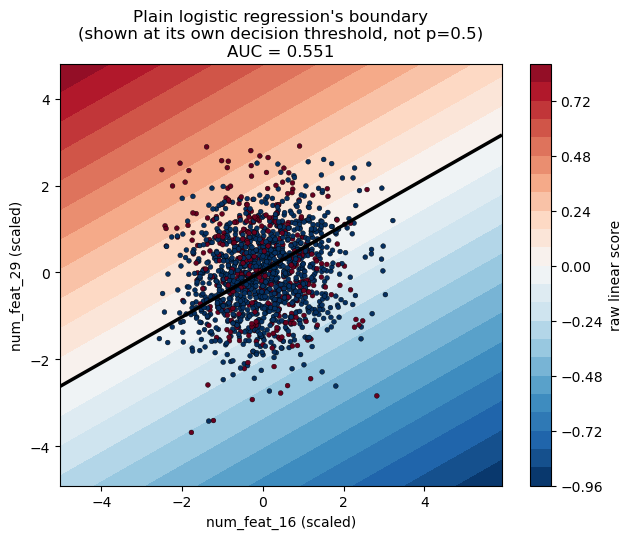

In [45]:
from sklearn.model_selection import train_test_split

f1, f2 = "num_feat_16", "num_feat_29"
sub = train[[f1, f2, "target"]].dropna()
X = sub[[f1, f2]].values; y = sub["target"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

lr = LogisticRegression(class_weight="balanced").fit(Xtr_s, ytr)
auc = roc_auc_score(yte, lr.predict_proba(Xte_s)[:, 1])

x_min, x_max = Xte_s[:, 0].min() - 1, Xte_s[:, 0].max() + 1
y_min, y_max = Xte_s[:, 1].min() - 1, Xte_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
zz = lr.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
lim = np.abs(zz).max()
im = ax.contourf(xx, yy, zz, levels=25, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.contour(xx, yy, zz, levels=[0], colors="black", linewidths=2.5)
idx = np.random.RandomState(0).choice(len(Xte_s), size=1500, replace=False)
ax.scatter(Xte_s[idx, 0], Xte_s[idx, 1], c=yte[idx], cmap="RdBu_r", edgecolor="k", linewidth=0.3, s=12)
ax.set_title(f"Plain logistic regression's boundary\n(shown at its own decision threshold, not p=0.5)\nAUC = {auc:.3f}")
ax.set_xlabel(f"{f1} (scaled)"); ax.set_ylabel(f"{f2} (scaled)")
plt.colorbar(im, ax=ax, label="raw linear score")
plt.tight_layout()
plt.show()


The straight decision boundary that logistic regression uses, makes it difficult to separate the two target classes, since the true relationship between these features and the target is not linear, as few as two features already show a pattern. From the above visual, it shows that no single straight line can correctly divide the two classes (James et al., 2021).

## Next experiment: Logistic Regression with Polynomial features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

preprocess_interactions = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("interactions", PolynomialFeatures(degree=2, interaction_only=False, include_bias=True)),
    ]), num_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_features),
])

interactions_pipeline = Pipeline([
    ("prep", preprocess_interactions),
    ("clf", LogisticRegression(
        max_iter=2000,
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=0
    )),
])

X = train[feature_cols]
y = train[target_col]

log_experiment(
    run_name="polynomial_features_logistic_regression_experiment_with_Degree_2_with_different_hyperparameters",
    pipeline=interactions_pipeline,
    config=real_config(interactions_pipeline, features="poly_degree2_with_squares", num_impute="median", cat_impute="most_frequent"),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model(
    run_name="polynomial_features_logistic_regression_experiment_with_Degree_2_with_different_hyperparameters",
    pipeline=interactions_pipeline
    )

[polynomial_features_logistic_regression_experiment_with_Degree_2_with_different_hyperparameters] validation ROC-AUC = 0.7852, CV ROC-AUC = 0.7834 (+/- 0.0032)
  (W&B logging failed for this run:  — local results still recorded below)
Saved model -> results/models/logistic_regression/polynomial_features_logistic_regression_experiment_with_Degree_2_with_different_hyperparameters.joblib
Saved details -> results/models/logistic_regression/polynomial_features_logistic_regression_experiment_with_Degree_2_with_different_hyperparameters.json


In [42]:
search_pipeline_interactions = Pipeline([
    ("prep", preprocess_interactions),
    ("clf", LogisticRegression(solver="saga", max_iter=2000, random_state=RANDOM_STATE)),
])

param_distributions = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__penalty": ["l1", "l2", "elasticnet"],
    "clf__l1_ratio": uniform(0, 1),
    "clf__class_weight": [None, "balanced"],
}

random_search_interactions = RandomizedSearchCV(
    search_pipeline_interactions,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),  # 3 folds, not 5, for speed first
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search_interactions.fit(X_train, y_train)

print("Best CV ROC-AUC:", random_search_interactions.best_score_)
print("Best params:", random_search_interactions.best_params_)
save_model(
    run_name="polynomial_logistic_reg_random_search",
    pipeline=random_search_interactions
)
print("Best parameters for polynomial logistic regression with random search")
random_search_interactions.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x7ddd5c198040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x790d3c7ac040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

Best CV ROC-AUC: 0.7891537227265272
Best params: {'clf__C': np.float64(0.011526449540315618), 'clf__class_weight': 'balanced', 'clf__l1_ratio': np.float64(0.9922115592912175), 'clf__penalty': 'l1'}
Saved model -> results/models/other/polynomial_logistic_reg_random_search.joblib
Saved details -> results/models/other/polynomial_logistic_reg_random_search.json
Best parameters for polynomial logistic regression with random search


{'clf__C': np.float64(0.011526449540315618),
 'clf__class_weight': 'balanced',
 'clf__l1_ratio': np.float64(0.9922115592912175),
 'clf__penalty': 'l1'}

Exception ignored in: <function ResourceTracker.__del__ at 0x70d1727a4040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x789c4dda0040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [47]:
best_interactions_pipeline = log_experiment(
    run_name="logreg-interactions-randomsearch-best",
    pipeline=random_search_interactions.best_estimator_,
    config={"model": "LogisticRegression", "features": "pairwise_interactions", "search": "RandomizedSearchCV", **random_search_interactions.best_params_},
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)


[logreg-interactions-randomsearch-best] validation ROC-AUC = 0.7926, CV ROC-AUC = 0.7908 (+/- 0.0029)
  (W&B logging failed for this run:  — local results still recorded below)


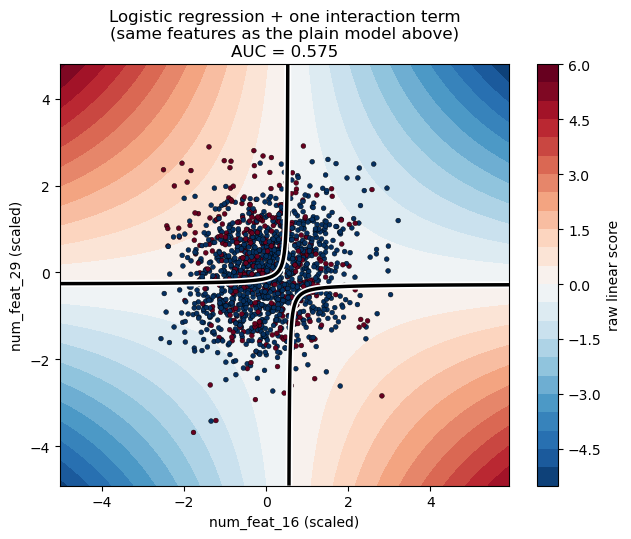

In [59]:
def add_interaction(Z):
    return np.column_stack([Z, Z[:, 0] * Z[:, 1]])

lr_poly = LogisticRegression(class_weight="balanced").fit(add_interaction(Xtr_s), ytr)
auc = roc_auc_score(yte, lr_poly.predict_proba(add_interaction(Xte_s))[:, 1])

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = lr_poly.decision_function(add_interaction(grid)).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
lim = np.abs(zz).max()
im = ax.contourf(xx, yy, zz, levels=25, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.contour(xx, yy, zz, levels=[0], colors="white", linewidths=5)    # halo, drawn first
ax.contour(xx, yy, zz, levels=[0], colors="black", linewidths=2.5)  # boundary, on top
idx = np.random.RandomState(0).choice(len(Xte_s), size=1500, replace=False)
ax.scatter(Xte_s[idx, 0], Xte_s[idx, 1], c=yte[idx], cmap="RdBu_r", edgecolor="k", linewidth=0.3, s=12)
ax.set_title(f"Logistic regression + one interaction term\n(same features as the plain model above)\nAUC = {auc:.3f}")
ax.set_xlabel(f"{f1} (scaled)"); ax.set_ylabel(f"{f2} (scaled)")
plt.colorbar(im, ax=ax, label="raw linear score")
plt.tight_layout()
plt.show()


### Train with RandomForestClassifier

This Random Forest uses `max_depth=None` so trees can grow fully, since Random Forest controls variance through bagging across many deep trees rather than by limiting each tree's depth individually. `min_samples_split=10` and `min_samples_leaf=5` are set as small fixed integers, not fractions of the dataset, so trees can still split deep enough to capture feature interactions while avoiding pure noise-fitting at the leaves.`max_features="sqrt"`  randomly subsamples features at each split to decorrelate the trees, and `class_weight="balanced_subsample"` is the natural fix for the current class imbalance of 74/26 without exploring more complex alternatives.

In [48]:
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier

preprocess_knn = ColumnTransformer([
    ("num", Pipeline([
        ("impute", KNNImputer(n_neighbors=5)),
        ("scale", StandardScaler()),
    ]), num_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_features),
])

random_forest = Pipeline([
    ("prep", preprocess_knn),
    ("clf", RandomForestClassifier(
    n_estimators=500,
    criterion="entropy",
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    max_samples=None,
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
),
])

log_experiment(
    run_name="random_forest_with_KNN_Inputing_and_regularization",
    pipeline=random_forest,
    config=real_config(random_forest, num_impute="knn_k5"),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model(
    run_name="random_forest_with_KNN_Inputing_and_regularization",
    pipeline=random_forest
)

[random_forest_with_KNN_Inputing_and_regularization] validation ROC-AUC = 0.7919, CV ROC-AUC = 0.7889 (+/- 0.0028)
  (W&B logging failed for this run:  — local results still recorded below)
Saved model -> results/models/random_forest/random_forest_with_KNN_Inputing_and_regularization.joblib
Saved details -> results/models/random_forest/random_forest_with_KNN_Inputing_and_regularization.json


This Random forest setup uses `min_samples_split=10` and `min_samples_leaf=5` are set as small fixed integers, not fractions of the dataset, so trees can still split deep enough to capture feature interactions while avoiding pure noise-fitting at the leaves. `max_features="sqrt"` randomly subsamples features at each split to decorrelate the trees, and class_weight="balanced_subsample" accounts for the dataset's class imbalance ~74/26 without exploring complex alternative. n_estimators is doubled to 1000 here (from 500 in the earlier run) to test whether more trees further stabilize the ensemble's predictions.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_median = Pipeline([
    ("prep", preprocess_exp1),
    ("clf", RandomForestClassifier(
        n_estimators=1000,
        criterion="entropy",
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        max_samples=None,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

log_experiment(
    run_name="random_forest_with_median_impute_and_regularization_2",
    pipeline=random_forest_median,
    config=real_config(random_forest_median, num_impute="median", dropped_duplicates=True),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)

[random_forest_median_impute_with_duplicates] validation ROC-AUC = 0.7982, CV ROC-AUC = 0.7962 (+/- 0.0027)


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
val_roc_auc,▁
cv_roc_auc_mean,0.79625
cv_roc_auc_std,0.00275
val_roc_auc,0.79824


Saved model -> results/models/random_forest_median_impute_with_duplicates.joblib
Saved details -> results/models/random_forest_median_impute_with_duplicates.json


This configuration is identical to the previous Random Forest, but reintroduces the three exact-duplicate columns num_feat_8, 18, 34, that were dropped earlier-- testing all 37 numeric features instead of the deduplicated 34. This was motivated by max_features="sqrt": with 37 features, each split samples 6 candidate features rather than 5, so duplicating an informative column raises its odds of being available at any given split. `min_samples_split=10` and `min_samples_leaf=5` remain small fixed integers rather than dataset fractions, letting trees split deep enough to exploit that extra sampling chance.

In [55]:
from sklearn.ensemble import RandomForestClassifier

num_features_with_duplicates = [c for c in train.columns if c.startswith("num_feat")]  # includes num_feat_8/18/34 again

preprocess_with_duplicates = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_features_with_duplicates),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_features),
])

random_forest_with_duplicates = Pipeline([
    ("prep", preprocess_with_duplicates),
    ("clf", RandomForestClassifier(
        n_estimators=1000,
        criterion="entropy",
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        max_samples=None,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

log_experiment(
    run_name="random_forest_median_impute_with_duplicates",
    pipeline=random_forest_with_duplicates,
    config=real_config(random_forest_with_duplicates, num_impute="median", dropped_duplicates=False),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model("random_forest_median_impute_with_duplicates", random_forest_with_duplicates)


[random_forest_median_impute_with_duplicates] validation ROC-AUC = 0.7982, CV ROC-AUC = 0.7962 (+/- 0.0027)


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
val_roc_auc,▁
cv_roc_auc_mean,0.79625
cv_roc_auc_std,0.00275
val_roc_auc,0.79824


Saved model -> results/models/random_forest_median_impute_with_duplicates.joblib
Saved details -> results/models/random_forest_median_impute_with_duplicates.json


## Train with XGBClassifier

This XGBoost model uses learning_rate=0.03 paired with `n_estimators=5000`, taking many small correction steps instead of a few large ones, which tends to generalize better. `max_depth=5` keeps trees shallow, consistent with boosting's weak-learner approach. `min_child_weight=3` requires a minimum number of samples per leaf before a split is allowed — XGBoost's analog to Random Forest's min_samples_leaf. `gamma=0.1` and `reg_lambda=2.0` add further regularization, pruning low-value splits and shrinking leaf weights respectively.

In [ ]:
from xgboost import XGBClassifier
xgb_pipeline_v2 = Pipeline([
    ("prep", preprocess_exp1),
    ("clf", XGBClassifier(
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_lambda=2.0,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

log_experiment(
    run_name="xgboost_median_impute_v2_tuned_1",
    pipeline=xgb_pipeline_v2,
    config=real_config(xgb_pipeline_v2, num_impute="median", dropped_duplicates=True),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model("xgboost_median_impute_v2_tuned_1", xgb_pipeline_v2)


[xgboost_median_impute_v2_tuned_1] validation ROC-AUC = 0.8272, CV ROC-AUC = 0.8252 (+/- 0.0026)
  (W&B logging failed for this run:  — local results still recorded below)
Saved model -> results/models/xgboost_median_impute_v2_tuned_1.joblib
Saved details -> results/models/xgboost_median_impute_v2_tuned_1.json


This XGBoost model pushes max_depth to 9 — much deeper than the typical boosting, but depth turned out to be the parameter that consistently helped on this dataset. It also switches to the full 37 features set, re-including the three duplicate columns (num_feat_8,18,34) that were dropped elsewhere. Since colsample_bytree=0.8 samples columns once per tree, duplicating an informative feature raises the odds at least one copy is included in any given tree: the same mechanism that helped Random Forest. min_child_weight=3, gamma=0.1, and reg_lambda=2.0 are carried over unchanged from the previous configuration to offset the added capacity from the deeper trees.

In [34]:
from xgboost import XGBClassifier

# All 37 numeric features (duplicates num_feat_8/18/34 re-included) — this was the best result
num_features_with_duplicates = [c for c in train.columns if c.startswith("num_feat")]

preprocess_with_duplicates = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_features_with_duplicates),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_features),
])

xgb_pipeline_best = Pipeline([
    ("prep", preprocess_with_duplicates),
    ("clf", XGBClassifier(
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=9,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_lambda=2.0,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

log_experiment(
    run_name="xgboost_median_impute_v2_tuned_with_duplicates_v3_increase_learning_rate_and_estimator_1_max",
    pipeline=xgb_pipeline_best,
    config=real_config(xgb_pipeline_best, num_impute="median", dropped_duplicates=False),
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model("xgboost_median_impute_v2_tuned_with_duplicates_v3_increase_learning_rate_and_estimator_1_max", xgb_pipeline_best)


[xgboost_median_impute_v2_tuned_with_duplicates_v3_increase_learning_rate_and_estimator_1_max] validation ROC-AUC = 0.8405, CV ROC-AUC = 0.8378 (+/- 0.0020)


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
val_roc_auc,▁
cv_roc_auc_mean,0.83781
cv_roc_auc_std,0.002
val_roc_auc,0.84048


Saved model -> results/models/xgboost_median_impute_v2_tuned_with_duplicates_v3_increase_learning_rate_and_estimator_1_max.joblib
Saved details -> results/models/xgboost_median_impute_v2_tuned_with_duplicates_v3_increase_learning_rate_and_estimator_1_max.json


### CatBoostClassifier
Since the result with the previous XGBoost prove that training with all features set affect performance, this CatBoost uses all the 37 features

This CatBoost model uses depth=10 with `iterations=3000` and `learning_rate=0.03`, following the same depth-matters pattern found with XGBoost. Unlike the other pipelines, categorical columns are passed directly via cat_features rather than one-hot encoded, letting CatBoost use its own target-statistics-based encoding internally. Numeric columns are passed through untouched ("passthrough") since CatBoost handles missing values natively, without needing a separate imputer.`l2_leaf_reg=3` applies L2 regularization to leaf values, and scale_pos_weight is computed from the training data's class ratio to correct for the imbalance.



In [ ]:
from catboost import CatBoostClassifier

num_all = [c for c in train.columns if c.startswith("num_feat")]

prep_cb = ColumnTransformer([
    ("num", "passthrough", num_all),
    ("cat", SimpleImputer(strategy="constant", fill_value="missing"), cat_features),
], verbose_feature_names_out=False).set_output(transform="pandas")

cb_pipeline = Pipeline([
    ("prep", prep_cb),
    ("clf", CatBoostClassifier(
        iterations=3000,
        learning_rate=0.03,
        depth=10,
        l2_leaf_reg=3,
        scale_pos_weight=float((y_train == 0).sum() / (y_train == 1).sum()),
        eval_metric="AUC",
        cat_features=tuple(cat_features),
        random_seed=RANDOM_STATE,
        verbose=0,
        thread_count=-1,
    )),
])

log_experiment(
    run_name="catboost_depth10_3000iter_CV",
    pipeline=cb_pipeline,
    config={"model": "CatBoostClassifier", **cb_pipeline.named_steps["clf"].get_params(),
            "num_impute": "none (CatBoost handles NaN)", "dropped_duplicates": False},
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model("catboost_depth10_3000iter_CV", cb_pipeline)


[catboost_depth10_3000iter_CV] validation ROC-AUC = 0.8617, CV ROC-AUC = 0.8617 (+/- 0.0042)
  (W&B logging failed for this run:  — local results still recorded below)
Saved model -> results/models/catboost_depth8_3000iter_CV.joblib
Saved details -> results/models/catboost_depth8_3000iter_CV.json


This CatBoost model is identical to the `depth-10` version except depth is pushed to `11`, continuing to test whether more depth keeps helping. `verbose=200` prints training progress every `200 iterations` instead of staying silent, and `allow_writing_files=False` stops CatBoost from writing its own log files to disk. The single RUN variable is used for both log_experiment and save_model, so the logged run and the saved model file can't end up with mismatched names.

In [20]:
assert "model_folder" in globals(), "Run the save_model cell first (the one that starts with import joblib)"
from catboost import CatBoostClassifier

RUN = "catboost_depth11_3000iter_cv"      # one name, used everywhere below
num_all = [c for c in train.columns if c.startswith("num_feat")]

prep_cb = ColumnTransformer([
    ("num", "passthrough", num_all),
    ("cat", SimpleImputer(strategy="constant", fill_value="missing"), cat_features),
], verbose_feature_names_out=False).set_output(transform="pandas")

cb_d11 = Pipeline([
    ("prep", prep_cb),
    ("clf", CatBoostClassifier(
        iterations=3000,
        learning_rate=0.03,
        depth=11,
        l2_leaf_reg=3,
        scale_pos_weight=float((y_train == 0).sum() / (y_train == 1).sum()),
        eval_metric="AUC",
        cat_features=tuple(cat_features),
        random_seed=RANDOM_STATE,
        verbose=200,
        thread_count=-1,
        allow_writing_files=False,
    )),
])

log_experiment(
    run_name=RUN,
    pipeline=cb_d11,
    config={"model": "CatBoostClassifier", **cb_d11.named_steps["clf"].get_params(),
            "num_impute": "none (CatBoost handles NaN)", "dropped_duplicates": False},
    X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    X_full=X, y_full=y,
    do_cv=True,
)
save_model(RUN, cb_d11)


0:	total: 317ms	remaining: 15m 49s
200:	total: 54.3s	remaining: 12m 36s
400:	total: 1m 52s	remaining: 12m 11s
600:	total: 2m 48s	remaining: 11m 14s
800:	total: 3m 47s	remaining: 10m 23s
1000:	total: 4m 42s	remaining: 9m 25s
1200:	total: 5m 37s	remaining: 8m 25s
1400:	total: 6m 24s	remaining: 7m 18s
1600:	total: 7m 9s	remaining: 6m 15s
1800:	total: 7m 54s	remaining: 5m 15s
2000:	total: 8m 39s	remaining: 4m 19s
2200:	total: 9m 25s	remaining: 3m 25s
2400:	total: 10m 9s	remaining: 2m 31s
2600:	total: 10m 53s	remaining: 1m 40s
2800:	total: 11m 38s	remaining: 49.6s
2999:	total: 12m 22s	remaining: 0us
0:	total: 222ms	remaining: 11m 4s
200:	total: 43.5s	remaining: 10m 5s
400:	total: 1m 30s	remaining: 9m 49s
600:	total: 2m 18s	remaining: 9m 12s
800:	total: 3m 4s	remaining: 8m 27s
1000:	total: 3m 51s	remaining: 7m 42s
1200:	total: 4m 38s	remaining: 6m 57s
1400:	total: 5m 26s	remaining: 6m 12s
1600:	total: 6m 13s	remaining: 5m 26s
1800:	total: 7m	remaining: 4m 39s
2000:	total: 7m 47s	remaining: 3

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


[catboost_depth11_3000iter_cv] validation ROC-AUC = 0.8654, CV ROC-AUC = 0.8635 (+/- 0.0050)
  (W&B logging failed for this run:  — local results still recorded below)
Saved model -> results/models/cat/catboost_depth11_3000iter_cv.joblib
Saved details -> results/models/cat/catboost_depth11_3000iter_cv.json


## 7. Generating a Submission

This cell turns **any** fitted pipeline into a correctly-formatted submission file. It uses the baseline as the example — swap in your best model once you have one.

**Format check:** `sample_submission.csv` has two columns — `id` and `target` — where `target` is a **predicted probability**, not a 0/1 label. Using `predict_proba(...)[:, 1]` (not `predict(...)`) is what makes this correct.


In [ ]:
# Refit your chosen model on the FULL training set (not just the 80% split) before predicting on test
assert "model_folder" in globals(), "Run the save_model cell first (the one that starts with import joblib)"
final_name = "catboost_depth11_3000iter_cv"
final_model = cb_d11
final_model.fit(X, y)
test_probs = final_model.predict_proba(test[feature_cols])[:, 1]

submission = pd.DataFrame({
    "id": test["id"],
    "target": test_probs,
})

submission_path = os.path.join(DATA_DIR, f"submission_{final_name}.csv")
submission.to_csv(submission_path, index=False)

# keep the exact full-data model that produced this file, next to the other saved models
joblib.dump(final_model, os.path.join(model_folder(final_model), f"{final_name}_fulldata.joblib"))

print(submission.head())
print(f"\nSaved {submission_path} — {submission.shape[0]} rows")

0:	total: 252ms	remaining: 12m 36s
200:	total: 46.5s	remaining: 10m 48s
400:	total: 1m 31s	remaining: 9m 54s
600:	total: 2m 18s	remaining: 9m 13s
800:	total: 3m 9s	remaining: 8m 39s
1000:	total: 3m 58s	remaining: 7m 57s
1200:	total: 4m 48s	remaining: 7m 12s
1400:	total: 5m 35s	remaining: 6m 23s
1600:	total: 6m 23s	remaining: 5m 34s
1800:	total: 7m 10s	remaining: 4m 46s
2000:	total: 7m 56s	remaining: 3m 58s
2200:	total: 8m 43s	remaining: 3m 10s
2400:	total: 9m 30s	remaining: 2m 22s
2600:	total: 10m 16s	remaining: 1m 34s
2800:	total: 11m 2s	remaining: 47.1s
2999:	total: 11m 48s	remaining: 0us
           id    target
0  row_007104  0.359146
1  row_006043  0.012477
2  row_007861  0.011557
3  row_047137  0.026909
4  row_010138  0.061583

Saved ./data/submission_catboost_depth11_3000iter_cv.csv — 20000 rows


### How to submit this file to Kaggle

1. Go to the competition page → **Submit Predictions** (or the button on the Overview tab).
2. Upload `submission.csv` (download it first if you're on Colab: files panel → download; on Kaggle Notebooks it's already in your working directory).
3. Add a short description, e.g. `"baseline logistic regression"` or `"tuned random forest, run rf_n400_depth10"` — matching your W&B run name makes it easy to trace later.
4. Check your score on the **Leaderboard** tab once scoring finishes — this is your **public** score. Remember: your grade is based on the **private** leaderboard, revealed after the deadline. Don't over-optimize for the number you can see.
5. Repeat with your own models — you get up to 5 submissions/day, and can select up to 2 as your final submissions for grading.


## 8. Results Table

Auto-built from everything logged via `log_experiment(...)` above — this should already contain your baseline and every experiment you ran. Add a `public_lb_score` and `wandb_run_url` column by hand once you've submitted to Kaggle and can see your W&B run links.


### Build the result table from the each model result json files

In [53]:
import glob
import pandas as pd

rows = []
for path in sorted(glob.glob("results/models/*/*.json")):
    record = json.load(open(path))
    if record is None:
        continue
    rows.append(record)

rows += [
    {"run_name": "baseline-logreg", "model": "LogisticRegression",
     "val_roc_auc": 0.6567, "cv_roc_auc_mean": 0.6520},
    {"run_name": "logreg-randomsearch-best", "model": "LogisticRegression", "search": "RandomizedSearchCV",
     "val_roc_auc": 0.658, "cv_roc_auc_mean": 0.653},
    {"run_name": "logreg-interactions-randomsearch-best", "model": "LogisticRegression",
     "features": "pairwise_interactions", "search": "RandomizedSearchCV",
     "val_roc_auc": 0.7926, "cv_roc_auc_mean": 0.7908},
]

results_df = pd.DataFrame(rows)

PUBLIC_LB = {
    "baseline-logreg": 0.65753,
    "logreg-interactions-randomsearch-best": 0.79158,
    "xgboost_median_impute_v2_tuned_with_duplicates_v3_increase_learning_rate_and_estimator_1_max": 0.85355,
    "catboost_depth8_3000iter_cv": 0.86529,
    "catboost_depth10_3000iter_cv": 0.87507,
    "catboost_depth11_3000iter_cv": 0.87650,
}
results_df["public_lb_score"] = results_df["run_name"].map(PUBLIC_LB)
results_df["wandb_run_url"] = "https://wandb.ai/b-murairi-african-leadership-university/formative1-part2-BodeMurairi"

results_df = results_df.sort_values("val_roc_auc", ascending=False).reset_index(drop=True)
results_df


,run_name,model,iterations,learning_rate,depth,l2_leaf_reg,random_seed,verbose,eval_metric,scale_pos_weight,cat_features,num_impute,dropped_duplicates,val_roc_auc,cv_roc_auc_mean,allow_writing_files,C,penalty,l1_ratio,solver,max_iter,cat_impute,class_weight,features,n_estimators,max_depth,criterion,min_samples_split,min_samples_leaf,max_features,min_child_weight,gamma,reg_lambda,subsample,colsample_bytree,search,public_lb_score,wandb_run_url
0,catboost_depth11_3000iter_cv,CatBoostClassifier,3000.0,0.03,11.0,3.0,42.0,200.0,AUC,2.81558,"[cat_region, cat_channel, cat_tier]",none (CatBoost handles NaN),False,0.8654,0.8635,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87650,https://wandb.ai/b-murairi-african-leadership-...
1,catboost_depth10_3000iter_cv,CatBoostClassifier,3000.0,0.03,10.0,3.0,42.0,0.0,AUC,2.81558,"[cat_region, cat_channel, cat_tier]",none (CatBoost handles NaN),False,0.8617,0.8617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87507,https://wandb.ai/b-murairi-african-leadership-...
2,catboost_depth8_4000iter_cv,CatBoostClassifier,4000.0,0.03,8.0,3.0,42.0,0.0,AUC,2.81558,"[cat_region, cat_channel, cat_tier]",none (CatBoost handles NaN),False,0.8534,0.8525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://wandb.ai/b-murairi-african-leadership-...
3,catboost_depth8_3000iter_cv,CatBoostClassifier,3000.0,0.03,8.0,3.0,42.0,0.0,AUC,2.81558,"[cat_region, cat_channel, cat_tier]",none (CatBoost handles NaN),False,0.8528,0.8520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.86529,https://wandb.ai/b-murairi-african-leadership-...
4,xgboost_median_impute_v2_tuned_with_duplicates...,XGBClassifier,NaN,0.03,NaN,NaN,NaN,NaN,NaN,2.81560,NaN,median,False,0.8405,0.8378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,9.0,NaN,NaN,NaN,NaN,3.0,0.1,2.0,0.8,0.8,NaN,0.85355,https://wandb.ai/b-murairi-african-leadership-...
5,xgboost_median_impute_v2_tuned_with_duplicates...,XGBClassifier,NaN,0.03,NaN,NaN,NaN,NaN,NaN,2.81560,NaN,median,False,0.8400,0.8359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,9.0,NaN,NaN,NaN,NaN,6.0,0.3,5.0,0.7,0.8,NaN,NaN,https://wandb.ai/b-murairi-african-leadership-...
6,xgboost_median_impute_v2_tuned_with_duplicates...,XGBClassifier,NaN,0.04,NaN,NaN,NaN,NaN,NaN,2.81560,NaN,median,False,0.8396,0.8338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,11.0,NaN,NaN,NaN,NaN,6.0,0.3,5.0,0.7,0.7,NaN,NaN,https://wandb.ai/b-murairi-african-leadership-...
7,xgboost_median_impute_v2_tuned_with_duplicates...,XGBClassifier,NaN,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,median,False,0.8370,0.8349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000.0,5.0,NaN,NaN,NaN,NaN,3.0,0.1,2.0,NaN,NaN,NaN,NaN,https://wandb.ai/b-murairi-african-leadership-...
8,xgboost_median_impute_v2_tuned_with_duplicates...,XGBClassifier,NaN,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,median,False,0.8370,0.8349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000.0,5.0,NaN,NaN,NaN,NaN,3.0,0.1,2.0,NaN,NaN,NaN,NaN,https://wandb.ai/b-murairi-african-leadership-...
9,xgboost_median_impute_v2_tuned_with_duplicates...,XGBClassifier,NaN,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,median,False,0.8369,0.8352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000.0,5.0,NaN,NaN,NaN,NaN,3.0,0.1,2.0,NaN,NaN,NaN,NaN,https://wandb.ai/b-murairi-african-leadership-...


## 9. Discussion
Across the eight models in this notebook, changing the model’s ability to represent feature interactions produced much larger gains than most hyperparameter changes within a fixed model family. The baseline logistic regression (`baseline-logreg`) reached only 0.6567 validation ROC-AUC (0.65753 public leaderboard), and further tuning through randomized search did not improve the result much. The correlation matrix helped explain why: no individual numeric feature had a Pearson correlation with the target exceeding `r = 0.06`. This did not mean that the dataset had no relationship; rather, it suggested that the signal was not strongly linear in any individual feature. In fact, visualizing a plain logistic regression’s decision boundary on two features (`num_feat_16`, `num_feat_29`) made this limitation concrete: the model could only produce a flat, straight decision boundary (James et al., 2021), while the observed target rate across a quadrant split of these two features showed a localized spike (0.322 in one quadrant versus ≈0.23–0.26 in the others) that a simple linear boundary could not isolate. This is one of the reasons that led me not to try any other linear-based model such as SGDClassifier. On the other hand, adding pairwise interaction terms with `PolynomialFeatures` allowed logistic regression to represent curved decision boundaries, raising performance to 0.7926 validation ROC-AUC (`logreg-interactions-randomsearch-best`, 0.79158 public leaderboard). This was a gain of more than 13 ROC-AUC points from changing the feature representation alone, without changing the underlying model family.

Tree-based and boosting methods, on the contrary, captured this same interaction structure automatically, without requiring explicitly engineered polynomial terms. Within CatBoost, depth was consistently more consequential than simply adding more boosting iterations: validation ROC-AUC increased from 0.8528 at depth 8, to 0.8617 at depth 10, and to 0.8654 at depth 11 (`catboost_depth8_3000iter_cv`, `catboost_depth10_3000iter_cv`, `catboost_depth11_3000iter_cv`). In contrast, increasing the number of iterations from 3000 to 4000 at fixed depth produced almost no change (0.8528 vs 0.8534). Taken together, these results suggest that the dataset’s useful relationship requires enough tree depth to represent multi-way feature interactions, whereas simply extending the boosting process with additional iterations provides comparatively little benefit once the trees have sufficient capacity. A parallel-coordinates view across all logged runs in W&B (axes: `max_depth`, `learning_rate`, `iterations`, `n_estimators`, `cv_roc_auc_mean`, `val_roc_auc`) confirmed this pattern visually — the best-scoring runs (val ROC-AUC ≈0.86–0.88) consistently clustered around higher `max_depth` (9–11) and lower `learning_rate` (≈0.03), reinforcing the depth-matters-more-than-iterations conclusion above.

One unexpected finding came from re-including features that had a correlation of exactly 1.0 with three other features in the dataset. These features have been initially dropped due to the redundancy they bring. Contrary to the initial assumption that duplicates could not add information, retaining them produced measurable improvements in both Random Forest and XGBoost. The most plausible reason is their feature-subsampling strategy: Random Forest randomly selects a subset of columns for consideration at each split (`max_features`)(Breiman, 2001), while XGBoost can randomly subsample columns for each tree through `colsample_bytree`(Chen & Guestrin, 2016). Therefore, duplicating an informative feature increases the probability that at least a copy is available to a given tree or split, protecting the signal from being masked by feature subsampling. The duplicates do not introduce new information in themselves; rather, they can change how reliably existing information is exposed to the model.

cat_tier's labels (low, mid, high, premium) suggested a natural order, but its target rate did not follow one — low and mid were nearly identical (≈0.256), high dipped below both (≈0.242), and premium spiked above all three (≈0.296). This non-monotonic pattern was the basis for keeping cat_tier one-hot encoded (scikit-learn developers, n.d.) rather than converting it to a single ordinal numeric feature, since a linear ordinal code cannot represent a dip-then-spike relationship.

Finally, the gap between cross-validation and the public leaderboard remained remarkably stable across CatBoost’s three depth configurations. This consistency provides evidence that the validation results were tracking leaderboard performance reasonably well, rather than the observed improvements being driven purely by overfitting to a particular validation split. This same validation technique is a method I will carry on in my next projects. Lastly, the overall pattern across the experiments points toward interaction-rich, non-linear structure as the central characteristic of the dataset since linear models struggled until their feature representation was expanded through polynomial features, while tree-based models performed substantially better once given enough depth to capture the underlying interactions.

With more time, next steps would include testing models such as Kernel SVM, which is not restricted to linear decision boundaries and might capture the dataset's interactions differently from tree-based and gradient-boosting models. The next step would be blending predictions from the strongest models across families to see whether their distinct error patterns are complementary.


## 10. References

_List the competition/dataset link, and any papers, articles, or documentation you cited, in a consistent format (APA or IEEE)._

1. ApX Machine Learning. (n.d.). Polynomial features. In Introduction to feature engineering. [ApX Machine Learning course page](https://apxml.com/courses/intro-feature-engineering/chapter-5-feature-creation/polynomial-features)

2. Aguiar Quevedo, K., Fontana Bellorín, A., Jordá Jordá Aragón, C., & Aguilar-Gallardo, C. (2026). Impact of missing data imputation on the structure of real-world clinical datasets: A comparison of median, K-nearest neighbours, and MICE approaches. Research Square. https://doi.org/10.21203/rs.3.rs-10549611/v1

3. Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

4. Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785–794). Association for Computing Machinery. https://doi.org/10.1145/2939672.2939785

5. GeeksforGeeks. (2025, July 23). Logistic regression with polynomial features. [GeeksforGeeks article](https://www.geeksforgeeks.org/machine-learning/logistic-regression-with-polynomial-features/?utm_source=chatgpt.com)

6. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An introduction to statistical learning: With applications in R (2nd ed.). Springer. https://doi.org/10.1007/978-1-0716-1418-1 

7. scikit-learn developers. (n.d.). OneHotEncoder. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html 

